## Extracting and cleaning data with DuckDB and Pandas


In [10]:
import pandas as pd

pd.set_option("display.max_columns", None)  # show all cols
pd.set_option("display.max_colwidth", None)  # show full width of showing cols
pd.set_option(
    "display.expand_frame_repr", False
)  # print cols side by side as it's supposed to be

In [11]:
# Nous commencons par importer les librairies nécessaires pour l'analyse des données.

import duckdb

ODIS_DUCKDB_FILE = "odis.duckdb"
PCC_DUCKDB_FILE = "dev.duckdb"

con = duckdb.connect(database=PCC_DUCKDB_FILE, read_only=True)
con.sql(f"ATTACH '{ODIS_DUCKDB_FILE}' AS odis;")

BinderException: Binder Error: Failed to attach database: database with name "odis" already exists

In [12]:
# informacion de comunas y riesgos
query_catnat = """
SELECT *
  FROM dev.main.catnat_gaspar
  ORDER BY cod_commune ASC;
"""

cat_nat_2000 = con.sql(query_catnat)
cat_nat_2000_df = cat_nat_2000.df()

query_odis1 = """SELECT * FROM odis.gold_gold_com_dep_reg
ORDER BY CODGEO ASC;"""
odis_geolocalisation = con.sql(query_odis1).df()
odis_geolocalisation.head(2)

query_odis2 = """SELECT * FROM odis.gold_gold_emploi_demandeur
ORDER BY codgeo ASC;
"""
odis_emploi_demandeur = con.sql(query_odis2).df()
odis_emploi_demandeur["codgeo"] = odis_emploi_demandeur["codgeo"].str.zfill(5)


query_odis3 = """SELECT * FROM odis.gold_gold_typologies_territoires
ORDER BY codgeo ASC;"""
odis_topology = con.sql(query_odis3).df()


query_odis4 = """SELECT * FROM odis.gold_gold_population_taux_pauvrete
ORDER BY codgeo ASC;"""
odis_population_taux_pauvrete = con.sql(query_odis4).df()


In [13]:
# Cleaning Climate data
from datetime import datetime

cat_nat_2000_df.head(10)
climate_data = pd.DataFrame(
    {
        "lib_commune": cat_nat_2000_df["lib_commune"],
        "cod_commune": cat_nat_2000_df["cod_commune"],
        "climate_risk": cat_nat_2000_df["lib_risque_jo"],
        "durée événement": pd.to_datetime(cat_nat_2000_df["dat_fin"], format="mixed")
        - pd.to_datetime(cat_nat_2000_df["dat_deb"], format="mixed"),
    }
)
df_climate = (
    climate_data.groupby(["cod_commune", "lib_commune", "climate_risk"])
    .agg(duree_total=("durée événement", "sum"), nb_events=("durée événement", "count"))
    .reset_index()
)
df_climate


,cod_commune,lib_commune,climate_risk,duree_total,nb_events
0,01001,L'Abergement-Clémenciat,Inondations et/ou Coulées de Boue,1 days 00:00:00,2
1,01002,L'Abergement-de-Varey,Inondations et/ou Coulées de Boue,5 days 00:00:00,2
2,01004,Ambérieu-en-Bugey,Inondations et/ou Coulées de Boue,39 days 00:00:00,4
3,01004,Ambérieu-en-Bugey,Mouvement de Terrain,30 days 00:00:00,1
4,01004,Ambérieu-en-Bugey,Sécheresse,817 days 02:00:00,5
...,...,...,...,...,...
104466,97616,Sada,Vents Cycloniques,2 days 00:00:00,1
104467,97617,Tsingoni,Chocs Mécaniques liés à l'action des Vagues,2 days 00:00:00,1
104468,97617,Tsingoni,Inondations et/ou Coulées de Boue,2 days 00:00:00,1
104469,97617,Tsingoni,Secousse Sismique,416 days 00:00:00,1


In [23]:
# Cleaning Socio-economic data
df_demandeur = (
    odis_emploi_demandeur.groupby("codgeo")
    .agg(nb_demandeurs=("Demandeurs_Emploi", "mean"))
    .reset_index()
)
odis_population_taux_pauvrete.fillna(0, inplace=True)
odis_population_taux_pauvrete["codgeo"] = (
    odis_population_taux_pauvrete["codgeo"].astype(str).str.zfill(5)
)

df_pauvrete = (
    odis_population_taux_pauvrete.groupby("codgeo")
    .agg(TP40=("TP40", "mean"), TP50=("TP50", "mean"), TP60=("TP60", "mean"))
    .reset_index()
)
merged = pd.merge(df_demandeur, df_pauvrete, left_on="codgeo", right_on="codgeo")
df_socio = pd.merge(
    merged, odis_topology, left_on="codgeo", right_on="codgeo"
).reset_index(drop=True)
df_socio.head(5)

,codgeo,nb_demandeurs,TP40,TP50,TP60,libellé,tranche_de_population,population
0,01004,1739.295775,5.0,9.0,17.0,Ambérieu-en-Bugey,Entre 10000 et 50000,15554
1,01033,1910.563380,6.0,11.0,17.0,Valserhône,Entre 10000 et 50000,16162
2,01034,883.098592,5.0,10.0,18.0,Belley,Entre 5000 et 10000,9270
3,01053,4945.915493,7.0,13.0,24.0,Bourg-en-Bresse,Entre 10000 et 50000,42065
4,01071,368.873239,0.0,5.0,7.0,Cessy,Entre 5000 et 10000,5570


In [41]:
# Merging both datasets
df_merged = pd.merge(df_climate, df_socio, left_on="cod_commune", right_on="codgeo")
df_merged = df_merged.drop(columns=["codgeo", "lib_commune"])
df_merged.head(5)

,cod_commune,climate_risk,duree_total,nb_events,nb_demandeurs,TP40,TP50,TP60,libellé,tranche_de_population,population
0,01004,Inondations et/ou Coulées de Boue,39 days 00:00:00,4,1739.295775,5.0,9.0,17.0,Ambérieu-en-Bugey,Entre 10000 et 50000,15554
1,01004,Mouvement de Terrain,30 days 00:00:00,1,1739.295775,5.0,9.0,17.0,Ambérieu-en-Bugey,Entre 10000 et 50000,15554
2,01004,Sécheresse,817 days 02:00:00,5,1739.295775,5.0,9.0,17.0,Ambérieu-en-Bugey,Entre 10000 et 50000,15554
3,01033,Inondations et/ou Coulées de Boue,11 days 00:00:00,4,1910.563380,6.0,11.0,17.0,Valserhône,Entre 10000 et 50000,16162
4,01033,Mouvement de Terrain,64 days 00:00:00,2,1910.563380,6.0,11.0,17.0,Valserhône,Entre 10000 et 50000,16162


In [61]:
df_merged["duree_total"] = df_merged["duree_total"].dt.total_seconds() / 60


## Graphs


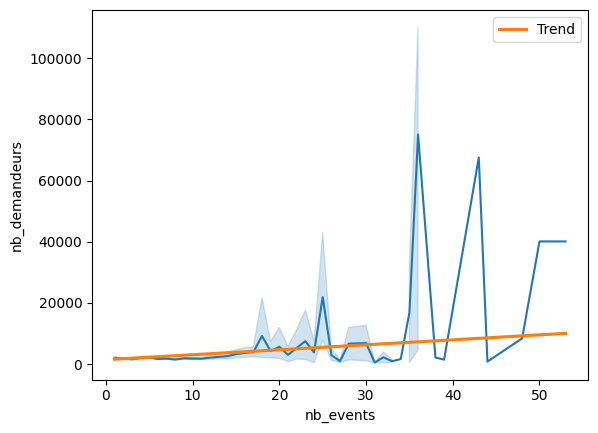

In [64]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.lineplot(data=df_merged, x="nb_events", y="nb_demandeurs")

sns.regplot(
    data=df_merged,
    x="nb_events",
    y="nb_demandeurs",
    scatter=False,  # no puntos
    ci=False,  # sin intervalo de confianza
    label="Trend",
)

plt.legend()
plt.show()

In [67]:
df_merged["duree_total"].head(5)

0      56160.0
1      43200.0
2    1176600.0
3      15840.0
4      92160.0
Name: duree_total, dtype: float64

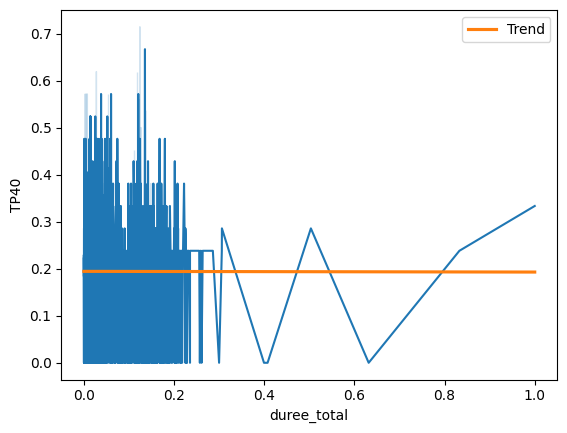

In [81]:
from sklearn.preprocessing import MinMaxScaler
import numpy as np

scaler = MinMaxScaler()
df_scaled = df_merged.copy()
df_scaled[["TP40", "duree_total"]] = scaler.fit_transform(
    df_merged[["TP40", "duree_total"]]
)

sns.lineplot(data=df_scaled, x="duree_total", y="TP40")
sns.regplot(
    data=df_scaled,
    x="duree_total",
    y="TP40",
    scatter=False,
    ci=False,
    label="Trend",
)

plt.legend()
plt.show()

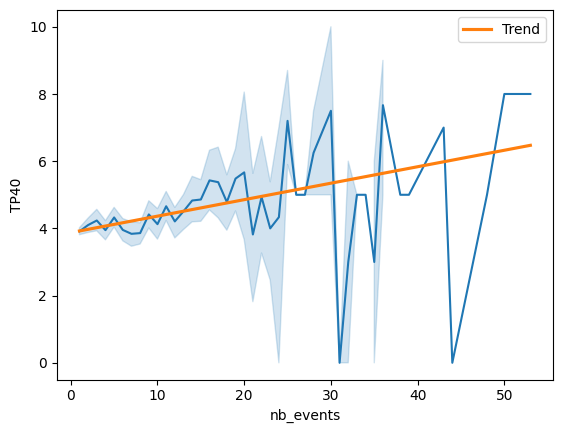

In [56]:
sns.lineplot(data=df_merged, x="nb_events", y="TP40")
sns.regplot(
    data=df_merged,
    x="nb_events",
    y="TP40",
    scatter=False,  # no puntos
    ci=False,  # sin intervalo de confianza
    label="Trend",
)

plt.legend()
plt.show()

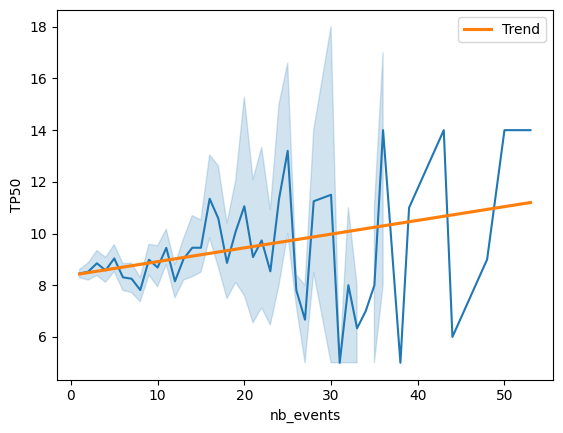

In [63]:
sns.lineplot(data=df_merged, x="nb_events", y="TP50")
sns.regplot(
    data=df_merged, x="nb_events", y="TP50", scatter=False, ci=True, label="Trend"
)

plt.legend()
plt.show()

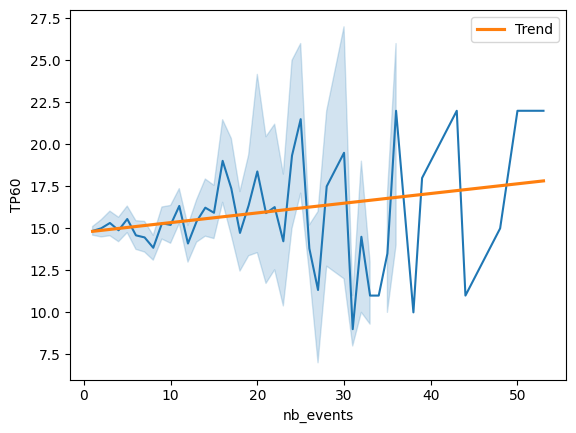

In [54]:
sns.lineplot(data=df_merged, x="nb_events", y="TP60")
sns.regplot(
    data=df_merged,
    x="nb_events",
    y="TP60",
    scatter=False,  # no puntos
    ci=False,  # sin intervalo de confianza
    label="Trend",
)

plt.legend()
plt.show()

## Correlations


In [90]:
df_merged.columns

Index(['cod_commune', 'climate_risk', 'duree_total', 'nb_events',
       'nb_demandeurs', 'TP40', 'TP50', 'TP60', 'libellé',
       'tranche_de_population', 'population'],
      dtype='str')

In [98]:
# All correaltions done with different methods show a week correlation, lower than 0.1
corr1 = df_merged[["nb_events", "nb_demandeurs"]].corr(method="spearman")
print(corr1)

corr2 = df_merged[["nb_events", "nb_demandeurs"]].corr(method="pearson")
print(corr2)

corr3 = df_merged[["nb_events", "nb_demandeurs"]].corr(method="kendall")
print(corr3)

corr4 = df_merged[["nb_events", "TP60"]].corr(method="spearman")
print(corr4)

corr5 = df_merged[["nb_events", "TP60"]].corr(method="pearson")
print(corr5)

corr6 = df_merged[["nb_events", "TP60"]].corr(method="kendall")
print(corr6)


               nb_events  nb_demandeurs
nb_events       1.000000       0.090525
nb_demandeurs   0.090525       1.000000
               nb_events  nb_demandeurs
nb_events        1.00000        0.10749
nb_demandeurs    0.10749        1.00000
               nb_events  nb_demandeurs
nb_events       1.000000       0.065638
nb_demandeurs   0.065638       1.000000
           nb_events      TP60
nb_events   1.000000  0.029904
TP60        0.029904  1.000000
           nb_events      TP60
nb_events   1.000000  0.035963
TP60        0.035963  1.000000
           nb_events      TP60
nb_events   1.000000  0.022149
TP60        0.022149  1.000000


## Regression


In [107]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error


X = df_merged[["nb_demandeurs", "TP40", "TP50", "TP60"]]
y = df_merged["nb_events"]


model = LinearRegression()
model.fit(X, y)

y_pred = model.predict(X)

r2 = r2_score(y, y_pred)
print("R^2:", r2)
mse = mean_squared_error(y, y_pred)
print("MSE:", mse)

R^2: 0.01729315883005278
MSE: 22.644224685200847


## Conclusion


For now, I could not find any significant correlation between the number of events and the socio-economic indicators. I will try to explore other variables and methods to see if there are any hidden relationships.
